---

# PCA — Principle Component Analysis

---

# 1. บทนำ: ปัญหาที่ PCA แก้ไข

ในงาน Data Science ข้อมูลมักมีจำนวน Feature จำนวนมาก เช่น:

* ข้อมูลลูกค้า 40–100 ตัวแปร
* ข้อมูลชีวการแพทย์หลายร้อยตัวแปร
* ข้อมูล sensor หรือ IoT หลายสิบมิติ

ปัญหาที่เกิดขึ้น:

1. Feature หลายตัวมีความสัมพันธ์กัน (multicollinearity)
2. โมเดลเทรนช้า
3. เกิด overfitting
4. ไม่สามารถ visualize ได้
5. ข้อมูลมี noise สูง

คำถามสำคัญคือ:

เราจะลดจำนวนมิติ (dimensionality) โดยยังคงสาระสำคัญของข้อมูลไว้ได้อย่างไร?

PCA คือคำตอบหนึ่งของปัญหานี้

# 2. แนวคิดพื้นฐานของ PCA

## 2.1 PCA คืออะไร?

Principal Component Analysis (PCA) คือเทคนิคการลดมิติแบบ:

* Unsupervised
* Linear transformation
* Feature extraction

PCA ไม่ได้เลือก feature เดิม
แต่สร้าง “แกนใหม่” (principal components)
ที่อธิบายความแปรปรวนของข้อมูลได้มากที่สุด

## 2.2 ความหมายของ Variance ในบริบทของ PCA

Variance คือ “ระดับการกระจายของข้อมูล”

ใน PCA:

* ทิศทางที่มี variance สูง → มีข้อมูลมาก
* ทิศทางที่ variance ต่ำ → ข้อมูลซ้ำกันมาก

![Image](https://miro.medium.com/v2/0*jEIuEzHO-kIop-6-)

แนวคิดสำคัญ:

PCA พยายามหา “ทิศทางที่ข้อมูลกระจายมากที่สุด”

# 3. ปัญหาของแกนเดิม (Original Coordinate System)

พิจารณาข้อมูล 2 มิติ:

ถ้าข้อมูลเรียงตัวเป็นแนวทแยง
แกน X และ Y เดิมอาจไม่ใช่แกนที่อธิบายข้อมูลได้ดีที่สุด

![Image](https://miro.medium.com/1%2A_wcd4AGrcovM0m_WypIYtQ.png)

![Image](https://deepnote.com/publish/3c882279-82a6-4796-9acf-70d58cb2aa76/file?path=%2Fassets%2Fpca-illustration.jpg)

แนวคิดหลักของ PCA คือ:

หมุนแกนพิกัด (rotate coordinate system)
เพื่อให้แกนใหม่สอดคล้องกับทิศทางการกระจายของข้อมูล

# 4. ขั้นตอนการคิดของ PCA (Conceptual Steps)

1. วัดว่าข้อมูลกระจายไปทางไหนมากที่สุด
2. สร้างแกนใหม่ในทิศทางนั้น (PC1)
3. หาแกนที่ตั้งฉากและมี variance รองลงมา (PC2)
4. ทำซ้ำจนได้ครบทุกมิติ

คุณสมบัติสำคัญ:

* PC1 อธิบาย variance มากที่สุด
* PC2 อธิบาย variance ที่เหลือมากที่สุด
* Principal components ตั้งฉากกัน (orthogonal)

# 5. กลไกทางคณิตศาสตร์เบื้องหลัง PCA

หลังจากเราเข้าใจแล้วว่า:

* PCA คือการหมุนแกน
* PCA หาแกนที่ variance สูงที่สุด
* PCA ฉายข้อมูลลงบนแกนใหม่

คำถามสำคัญคือ:

**PCA รู้ได้อย่างไรว่าแกนไหนคือแกนที่ดีที่สุด?**

คำตอบอยู่ที่ 3 แนวคิดหลัก:

1. Covariance Matrix
2. Eigenvectors
3. Eigenvalues

## 5.1 Covariance Matrix: รูปร่างของข้อมูล

### 1) เริ่มจากคำถามพื้นฐาน

ถ้าเรามี feature สองตัว เช่น:

* X1 = alcohol
* X2 = color_intensity

เราจะรู้ได้อย่างไรว่า:

ข้อมูลกระจายไปทางไหน?

คำตอบคือ:

เราต้องรู้ว่า X1 และ X2 เปลี่ยนแปลงไปพร้อมกันหรือไม่

นี่คือบทบาทของ Covariance

### 2) ความหมายของ Covariance

Covariance วัดว่า:

* ถ้า X1 เพิ่ม X2 เพิ่มด้วยหรือไม่
* ถ้า X1 เพิ่ม X2 ลดลงหรือไม่

ถ้า covariance สูง (บวก):

> ข้อมูลมีแนวโน้มเรียงตัวเป็นแนวทแยงขึ้น

ถ้า covariance เป็นลบ:

> เรียงตัวเป็นแนวทแยงลง

ถ้า covariance ใกล้ศูนย์:

> ไม่มีแนวโน้มเอียงชัดเจน

### 3) Covariance Matrix คืออะไร

เมื่อมีหลาย feature
เราจะได้ตารางสรุปความสัมพันธ์ของทุกคู่ตัวแปร

![Image](https://miro.medium.com/1%2Abrq_vvcnVqsOWoVvsjT0pA.png)

ภาพนี้สื่อว่า:

* ช่องนอกแนวทแยง = ความสัมพันธ์ระหว่างตัวแปร
* ถ้ามีหลายค่าที่สูง → ข้อมูลมีโครงสร้างเอียงชัดเจน

### 4) ความสำคัญในบริบท PCA

Covariance matrix บอก “รูปทรงของกลุ่มข้อมูล”

ถ้าข้อมูลกระจายเป็นวงรี
covariance matrix จะสะท้อนทิศทางของวงรีนั้น

## 5.2 จาก Covariance สู่ Eigenvectors

เมื่อเราได้ covariance matrix แล้ว
PCA จะถามคำถามสำคัญ:

> ทิศทางใดที่ข้อมูลกระจายมากที่สุด?

คำตอบคือ:

> Eigenvector ของ covariance matrix

### 1) ความหมายเชิงแนวคิด

Eigenvector = ทิศทางพิเศษของข้อมูล
Eigenvalue = ปริมาณ variance ในทิศทางนั้น

พูดแบบง่าย:

* Eigenvector บอกว่า “แกนควรชี้ไปทางไหน”
* Eigenvalue บอกว่า “แกนนั้นสำคัญแค่ไหน”

### 2) เชื่อมกับภาพวงรี

![Image](https://cookierobotics.com/007/covariance_ellipse.png)

อธิบายภาพ:

* แกนยาวของวงรี = Eigenvector ที่ eigenvalue สูงสุด → PC1
* แกนรองลงมา = Eigenvector ที่ eigenvalue รองลงมา → PC2

## 5.3 สรุปเชิงแนวคิด

Covariance matrix  
> บอก “รูปร่างของข้อมูล”

Eigenvectors  
> บอก “แกนธรรมชาติของข้อมูล”

Eigenvalues  
> บอก “ความสำคัญของแกนนั้น”

PCA  
> เลือก eigenvectors ที่สำคัญที่สุด  
> ใช้เป็นแกนใหม่  
> ลดมิติข้อมูล  

# 6. การฉายข้อมูล (Projection)

เมื่อได้แกนใหม่แล้ว
เราจะฉายข้อมูลลงบนแกนเหล่านั้น

ตัวอย่าง: ลดจาก 2 มิติ → 1 มิติ

![Image](https://miro.medium.com/v2/resize%3Afit%3A1400/1%2AvUdgIorlMMzIzpVCvADmMQ.jpeg)

หากเลือกแกนที่ variance สูง
ข้อมูลจะสูญเสียน้อย

หากเลือกแกนที่ variance ต่ำ
ข้อมูลจะทับซ้อนและสูญเสียสาระสำคัญ

# 7. ขั้นตอนการทำ PCA ด้วย Python

## 7.1 โหลดข้อมูลตัวอย่าง (Wine Dataset)

In [40]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 7.2 Visualization ก่อนทำ PCA

ข้อจำกัด:

* เห็นได้แค่ 2 features
* ไม่เห็นภาพรวมทั้ง 13 มิติ

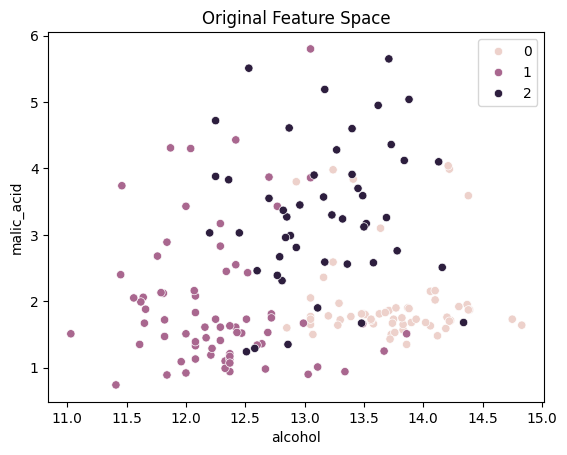

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=X['alcohol'], y=X['malic_acid'], hue=y)
plt.title("Original Feature Space")
plt.show()

## 7.3 Standardization (ขั้นตอนสำคัญ)

เหตุผล:

PCA sensitive ต่อ scale  
feature ที่ variance สูงจะมีอิทธิพลมากกว่า

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 7.4 ทำ PCA

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## 7.5 Visualization หลัง PCA

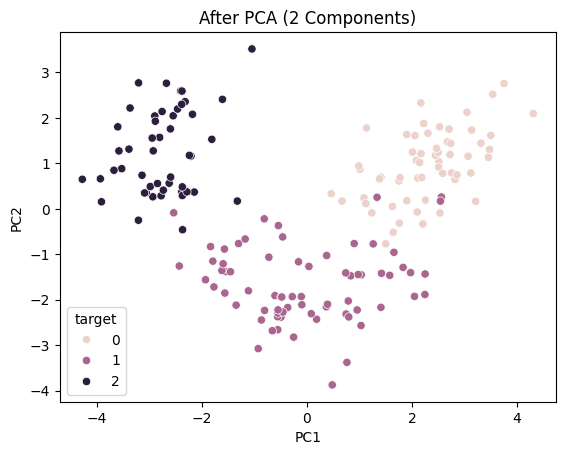

In [44]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='target')
plt.title("After PCA (2 Components)")
plt.show()

# 8. Explained Variance

ความหมาย:

* PC1 อธิบายข้อมูลกี่ %
* PC2 อธิบายเพิ่มอีกกี่ %
* รวมกันอธิบายได้เท่าใด

In [45]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 ])

#
## ตัวอย่างการ plot cumulative variance

แนวทางเลือกจำนวน components:

* 80–90% cumulative variance
* Elbow point

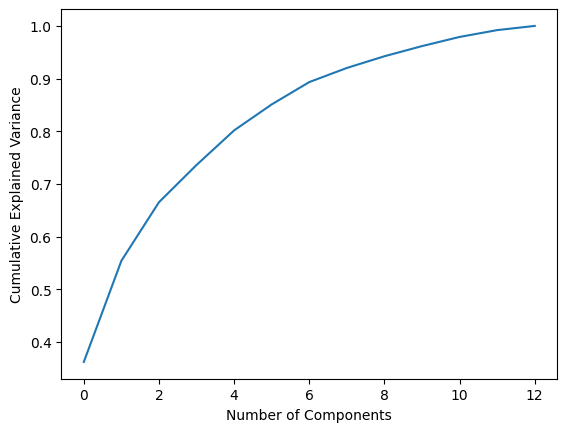

In [46]:
import numpy as np

pca_all = PCA()
X_pca_all = pca_all.fit_transform(X_scaled)

explained = pca_all.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.plot(cumulative)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

# 9. ความหมายเชิงตีความ (Interpretation)

แสดงว่า feature ใดมีอิทธิพลต่อ component

In [47]:
components = pd.DataFrame(
    pca.components_,
    columns=wine.feature_names
)
components

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.144329,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752
1,0.483652,0.224931,0.316069,-0.010591,0.299634,0.065040,-0.003360,0.028779,0.039302,0.529996,-0.279235,-0.164496,0.364903


#
## ข้อควรระวัง:

* Principal components เป็น linear combination
* ไม่ได้มีความหมายชัดเจนเสมอไป
* Interpretability ลดลงเมื่อเทียบกับ feature เดิม

# 10. PCA กับโมเดล

## เปรียบเทียบ Logistic Regression

### ก่อน PCA

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy (No PCA):", accuracy_score(y_test, y_pred))

Accuracy (No PCA): 0.9814814814814815


### หลัง PCA

In [49]:
pca_k = PCA(n_components=5)
X_reduced = pca_k.fit_transform(X_train)

model = LogisticRegression(max_iter=5000)
model.fit(X_reduced, y_train)

X_test_reduced = pca_k.transform(X_test)
y_pred = model.predict(X_test_reduced)

print("Accuracy (With PCA):", accuracy_score(y_test, y_pred))

Accuracy (With PCA): 0.9629629629629629


# 11. สรุปแนวคิดสำคัญ

PCA คือ:

* การหมุนแกนพิกัด
* การหาแกนที่ variance สูงที่สุด
* การฉายข้อมูลลงแกนใหม่
* การลดมิติแบบ linear
* การลด multicollinearity
* การลด noise

PCA ไม่ใช่:

* Feature selection
* Supervised method
* วิธีเพิ่ม accuracy เสมอไป

# 12. Discussion

1. PCA เหมาะกับข้อมูลลักษณะใด?
2. หาก feature ไม่ correlated กัน PCA ยังจำเป็นหรือไม่?
3. การทำ PCA ก่อน train-test split มีความเสี่ยงอย่างไร?
4. PCA ลด interpretability หรือไม่?

# 13. Hands-on

แสดง Visualization ของชุดข้อมูล Credit Card Fraud Detection (Kaggle) โดยใช้กระบวนการของ PCA เพื่อลดมิติของข้อมูลให้สามารถแสดงผลในรูปแบบ 2D ได้

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# โหลดข้อมูล Credit Card Fraud Detection
df = pd.read_csv('data/creditcard.csv')
print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Class'].value_counts())
print(f'\nFraud ratio: {df["Class"].mean()*100:.3f}%')
df.head()


Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud ratio: 0.173%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


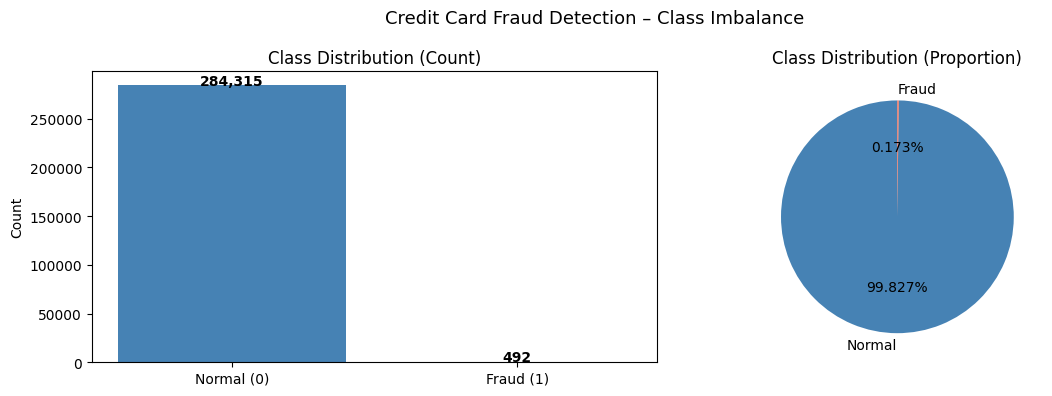

Normal: 284,315  |  Fraud: 492


In [51]:
# ---- Class distribution (bar chart) ----
class_counts = df['Class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'],
            colors=['steelblue', 'tomato'],
            autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (Proportion)')
plt.suptitle('Credit Card Fraud Detection – Class Imbalance', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Normal: {class_counts[0]:,}  |  Fraud: {class_counts[1]:,}')


In [52]:
# ============================================================
# 13.2 PCA – ลดมิติเหลือ 2D
# ============================================================

# ---- Prepare features (ตัด Class ออก) ----
features = df.drop('Class', axis=1)
labels   = df['Class']

# ---- Sample (ใช้ทั้ง fraud + สุ่ม normal เพื่อให้ visualize ได้ชัด) ----
fraud_df  = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0].sample(n=len(fraud_df)*5, random_state=42)
sample_df = pd.concat([fraud_df, normal_df]).sample(frac=1, random_state=42)

X_sample = sample_df.drop('Class', axis=1).values
y_sample = sample_df['Class'].values
print(f'Sample size: {len(sample_df):,}  (Fraud={fraud_df.shape[0]}, Normal={len(normal_df)})')

# ---- Scale ----
scaler_cc = StandardScaler()
X_sample_scaled = scaler_cc.fit_transform(X_sample)

# ---- PCA → 2 components ----
pca_cc = PCA(n_components=2, random_state=42)
X_2d   = pca_cc.fit_transform(X_sample_scaled)

var_explained = pca_cc.explained_variance_ratio_
print(f'PC1 explains: {var_explained[0]*100:.2f}%')
print(f'PC2 explains: {var_explained[1]*100:.2f}%')
print(f'Total:        {sum(var_explained)*100:.2f}%')


Sample size: 2,952  (Fraud=492, Normal=2460)
PC1 explains: 34.01%
PC2 explains: 7.47%
Total:        41.48%


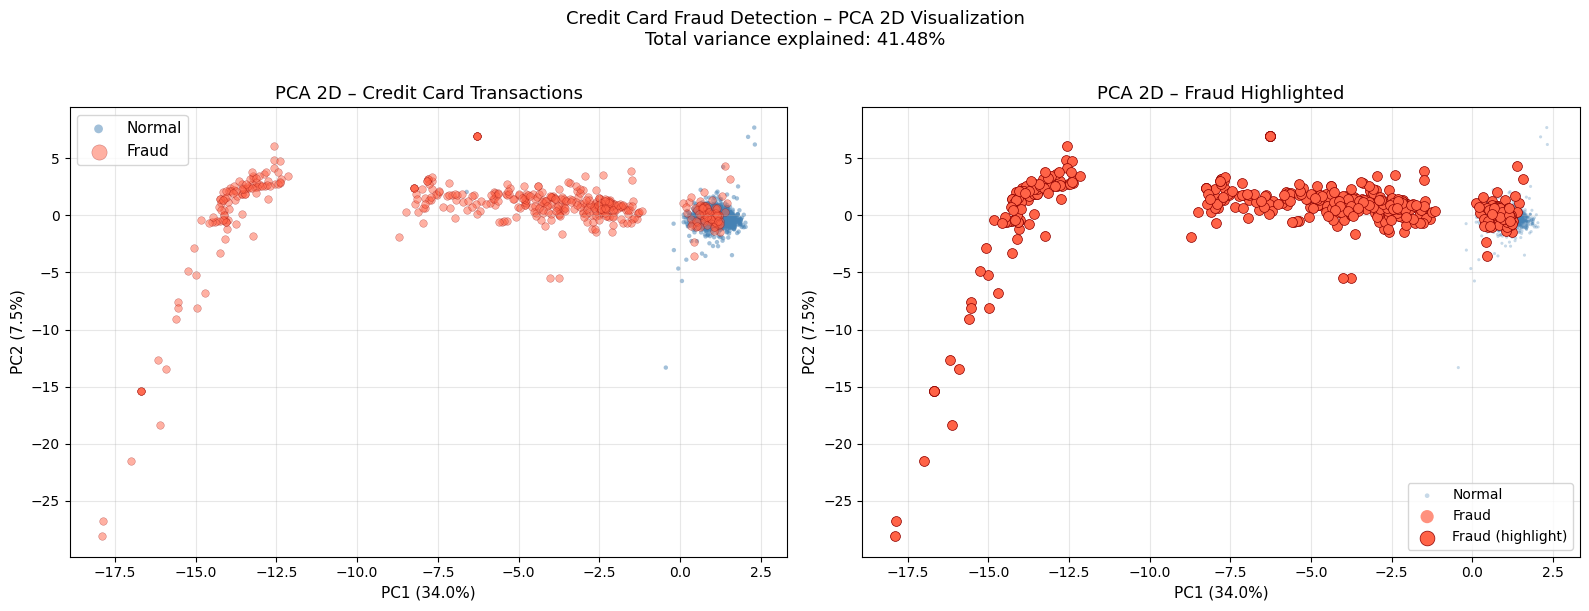

In [53]:
# ============================================================
# 13.3 Visualization – 2D PCA Scatter Plot
# ============================================================

colors = {0: 'steelblue', 1: 'tomato'}
labels_map = {0: 'Normal', 1: 'Fraud'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: Scatter สี Normal vs Fraud ----
for cls in [0, 1]:
    mask = y_sample == cls
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cls], label=labels_map[cls],
        alpha=0.5, s=10 if cls == 0 else 30,
        edgecolors='none' if cls == 0 else 'darkred', linewidths=0.3
    )
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('PCA 2D – Credit Card Transactions', fontsize=13)
axes[0].legend(markerscale=2, fontsize=11)
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Density / KDE overlay ----
for cls in [0, 1]:
    mask = y_sample == cls
    axes[1].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cls], label=labels_map[cls],
        alpha=0.3 if cls == 0 else 0.7,
        s=5 if cls == 0 else 40,
        edgecolors='none'
    )

# Highlight fraud region
fraud_mask = y_sample == 1
axes[1].scatter(X_2d[fraud_mask, 0], X_2d[fraud_mask, 1],
                c='tomato', s=50, edgecolors='darkred', linewidths=0.5,
                label='Fraud (highlight)', zorder=5)
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('PCA 2D – Fraud Highlighted', fontsize=13)
axes[1].legend(markerscale=1.5, fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Credit Card Fraud Detection – PCA 2D Visualization\n'
    f'Total variance explained: {sum(var_explained)*100:.2f}%',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


/Users/arincare/Web/lab-ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


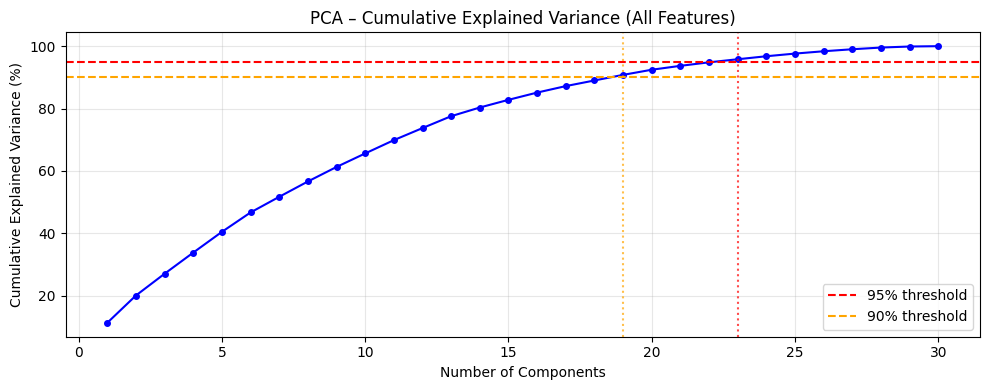

Components needed for 90% variance: 19
Components needed for 95% variance: 23
Total features: 30

→ PCA 2D captures 20.06% ของ variance ทั้งหมด


In [54]:
# ============================================================
# 13.4 Explained Variance – กี่ component ถึงพอ?
# ============================================================

pca_full = PCA(random_state=42)
pca_full.fit(scaler_cc.transform(features))

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components = features.shape[1]

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_components + 1), cumvar, 'b-o', markersize=4)
plt.axhline(y=95, color='r', linestyle='--', label='95% threshold')
plt.axhline(y=90, color='orange', linestyle='--', label='90% threshold')

n95 = np.argmax(cumvar >= 95) + 1
n90 = np.argmax(cumvar >= 90) + 1
plt.axvline(x=n95, color='r', linestyle=':', alpha=0.7)
plt.axvline(x=n90, color='orange', linestyle=':', alpha=0.7)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA – Cumulative Explained Variance (All Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Components needed for 90% variance: {n90}')
print(f'Components needed for 95% variance: {n95}')
print(f'Total features: {n_components}')
print(f'\n→ PCA 2D captures {cumvar[1]:.2f}% ของ variance ทั้งหมด')
